In [1]:
omega_m_marie = 0.2589 +- 0.0123
0.2594 +- 0.0074 #without expansion function (model-independent)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from scipy.optimize import curve_fit
import scipy.interpolate as interp
import camb
from camb import model, initialpower

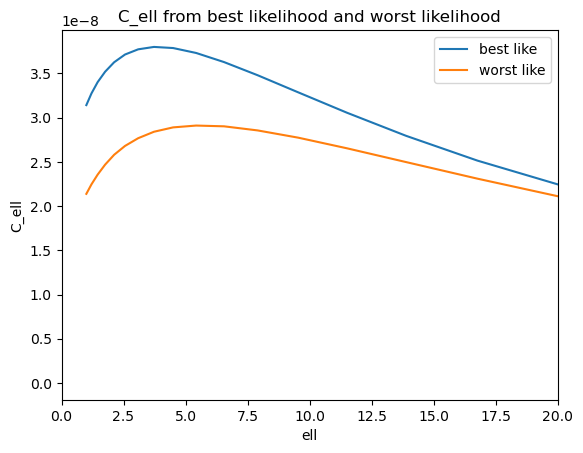

In [2]:
ells = np.loadtxt("ellsme.txt")
cell1 = np.loadtxt("c_ell_chain1.txt")
cell2 = np.loadtxt("c_ell_chain2.txt")
plt.plot(ells,cell2,label="best like")
plt.plot(ells,cell1,label="worst like")
plt.xlim(0,20)
plt.xlabel('ell')
plt.ylabel('C_ell')
plt.title('C_ell from best likelihood and worst likelihood')
plt.legend()

difference from chain (best like : -47.37) : 9.901585067882527e-09
difference from lcdm 60 (best like : -47.37) : 9.564538007841404e-09
difference from chain (good like : -47.39) : 9.803273663502498e-09
difference from lcdm 60 (good like : -47.39) : 9.564538007841404e-09
difference from chain (worst like : -967548.2720155459) : 3.0429130694189963e-06
difference from lcdm 60 (worst like : -967548.2720155459) : 9.564538007841404e-09
difference from chain (grad_des, like : -49.49) : 1.1886353035929366e-08
difference from lcdm 60 (grad_des, like : -49.49) : 9.564538007841404e-09


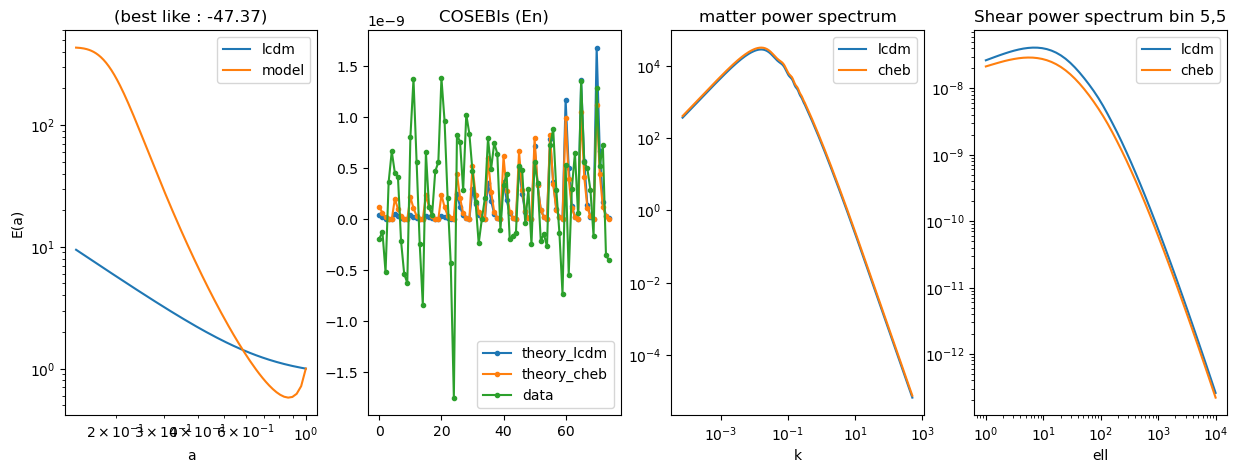

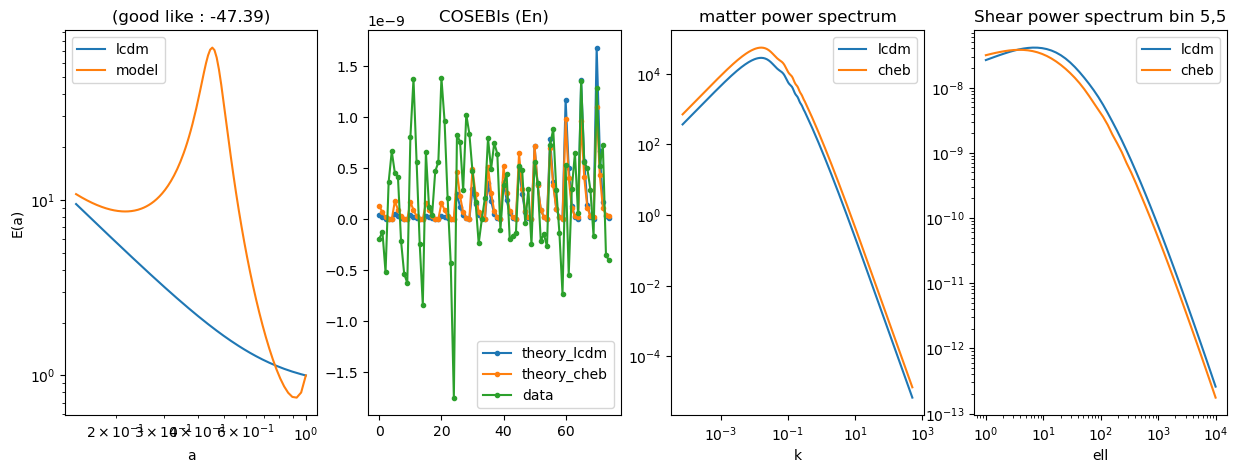

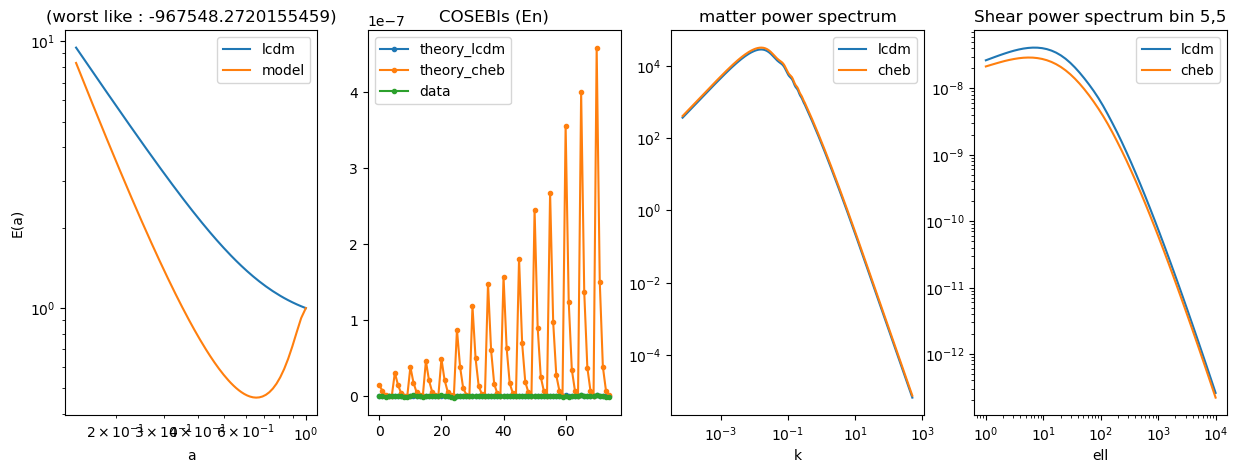

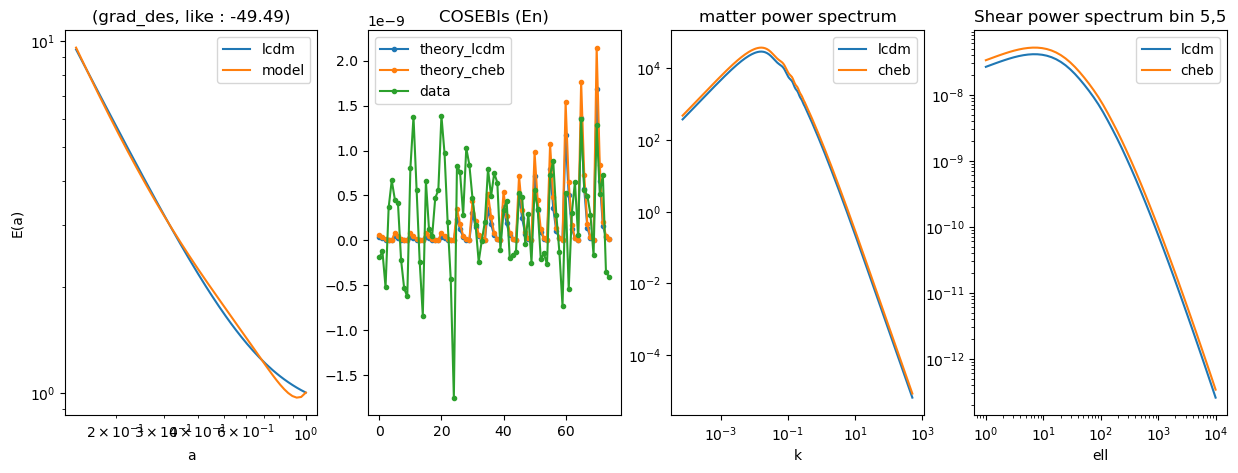

In [7]:
class model_independent:
    def __init__(self,c,a,h0=0.735,om=0.3596) :
        self.a = a
        self.da = (1-a[0])/a[0]
        self.x = (a-a[0])/(a[-1]-a[0])
        self.h0=h0
        self.om = om
        self.c = c

    def chebs (self,c,a) :
        x = np.arccos(a)
        result = 0
        for i in range(len(c)) :
            if i ==0 :
                result += (1/np.pi)**(1/2)*c[i]
            else :
                result += (2/np.pi)**(1/2)*c[i]*np.cos(i*x)
        return result
    
    def cheb_recursive(c,x) :
        n = len(c)
        t=np.zeros((n,x.shape[0]))
        # t[0]=(1/np.pi)**(1/2)
        # t[1]=(2/np.pi)**(1/2)*x
        t[0]=1
        t[1]=x
        for i in range(1,n-1) :
            t[i+1]=2*x*t[i]-t[i-1]
        for i in range(n):
            if i ==0 :
                t[i] *= (1/np.pi)**(1/2)
            else :
                t[i] *= (2/np.pi)**(1/2)
        result = 0
        for i in range(len(c)) :
            result += c[i]*t[i]
        return result
    
    def cheb(self,n,x) :
        n = n+1 #asking for the first poly, means asking for c0
        t=np.zeros((n,x.shape[0]))
        # t[0]=(1/np.pi)**(1/2)
        # t[1]=(2/np.pi)**(1/2)*x
        if n == 1 :
            t[0] = (1/np.pi)**(1/2)
            return t[0]
        t[0]=1
        t[1]=x
        for i in range(1,n-1) :
            t[i+1]=2*x*t[i]-t[i-1]
        for i in range(n):
            if i ==0 :
                t[i] *= (1/np.pi)**(1/2)
            else :
                t[i] *= (2/np.pi)**(1/2)
        return t
    
    def cheb_deriv(self,c,x) :
        n=len(c)
        q=np.zeros((n,x.shape[0]))
        t=np.zeros((n,x.shape[0]))
        t[0]=1
        t[1]=x
        for i in range(1,n-1) :
            t[i+1]=2*x*t[i]-t[i-1]
        for i in range(n):
            if i ==0 :
                t[i] *= (1/np.pi)**(1/2)
            else :
                t[i] *= (2/np.pi)**(1/2)
        q[0]=0
        q[1]=(2/np.pi)**(1/2)
        for i in range(1,n-1) :
            q[i+1]=2*t[i] + 2*x*q[i] - q[i-1]
        result = 0
        for i in range(n) :
            result += c[i]*q[i]
        return result
    
    def model_expf (self, c=None) :
        if c is None :
            c = self.c
        expf = self.da/(1+self.da*self.x)**2/self.chebs(c,2*self.x-1)/self.h0
        expf = expf/expf[-1]
        return expf
    
    def lcdm_expf (self) :
        omega_m = self.om
        omega_l = 1-omega_m
        expf = np.sqrt (omega_m/self.a**3 + omega_l)
        return expf
    
    def fit_model_to_lcdm (self,model_init,learning_rate = 0.1,n=10) :
        y_hat = model_init
        y = self.lcdm_expf()
        loss = np.sum(1/2*(y-y_hat)**2)
        print(loss)
        grad = np.zeros(len(self.c))
        grad_y = np.zeros((len(self.c),self.x.shape[0]))

        cheb_poly = self.cheb(len(self.c),2*self.x-1)
        
        for i in range(0,n+1) :
            for j in range(0,len(self.c)) :
                grad_y[j] = -self.da/self.h0 * cheb_poly[j]/(1+self.da*self.x)**2/self.chebs(self.c,2*self.x-1)**2
                grad[j] = np.sum((y_hat-y)*grad_y[j])

            self.c = self.c - learning_rate*grad
            y_hat = self.model_expf()
            loss = np.sum(1/2*(y-y_hat)**2)
            if i == 0 or i%1000==0:
                print(f"iteration {i} ",loss)
a = np.loadtxt("a_bg.txt")
me = model_independent(c,a,h0=0.6898,om=0.2589)
def combine(c,theory,pm,cell, comment="") :
    k = np.loadtxt("k_hme.txt")
    a = np.loadtxt("a_bg.txt")
    ells = np.loadtxt("ellsme.txt")
    pm_lcdm = np.loadtxt("pm_lin_60.txt")[0]
    cell_lcdm = np.loadtxt("c_ell_lin_60.txt")
    model = me.model_expf(c)
    lcdm = me.lcdm_expf()
    plt.figure(figsize=(15,5))
    plt.subplot(1,4,1)
    plt.loglog(a,lcdm,label="lcdm")
    plt.loglog(a,model,label="model")
    # plt.xlim(0.5,1)
    plt.ylabel("E(a)")
    plt.xlabel("a")
    plt.title(comment)
    plt.legend()

    dt60 = np.loadtxt("data-theory_data60_theory60.txt")
    diff_best_like = np.abs(theory-dt60[:,0])
    diff_lcdm_60 = np.abs(dt60[:,1]-dt60[:,0])
    n=40
    print("difference from chain", comment, ":", np.sum(diff_best_like[n:]))
    print("difference from lcdm 60", comment, ":" , np.sum(diff_lcdm_60[n:]))
    plt.subplot(1,4,2)
    plt.plot(dt60[:,1],label="theory_lcdm",marker = '.')
    plt.plot(theory, label = "theory_cheb",marker='.')
    plt.plot(dt60[:,0], label = "data",marker = '.')
    plt.title("COSEBIs (En)")
    plt.legend();

    plt.subplot(1,4,3)
    plt.loglog(k,pm_lcdm,label="lcdm")
    plt.loglog(k,pm,label="cheb")
    plt.legend();
    plt.xlabel('k')
    plt.title("matter power spectrum")

    plt.subplot(1,4,4)
    plt.loglog(ells,cell_lcdm,label="lcdm")
    plt.loglog(ells,cell,label="cheb")
    plt.legend();
    plt.xlabel('ell')
    plt.title("Shear power spectrum bin 5,5")


c = np.array([1.2851198795700602,   0.6716413042738609,    -0.5068379645337175,   -0.3515561649583212])
theory_best_like = np.loadtxt("data-theory_best_like_from_chain.txt", skiprows=1)[:,1]
pm = np.loadtxt("pm_chain1.txt")[0]
cell = np.loadtxt("c_ell_chain1.txt")
combine(c,theory_best_like,pm,cell,"(best like : -47.37)")

c = np.array([-1.3918258572100735,  0.5044126273601433,    -0.7474685206602097,    0.602843961283870])
theory = np.loadtxt("data-theory_chain2.txt",skiprows=1)[:,1]
pm = np.loadtxt("pm_chain2.txt")[0]
cell = np.loadtxt("c_ell_chain2.txt")
combine(c,theory,pm,cell,"(good like : -47.39)")

c = np.array([-0.9843438863754272,   0.47191232442855835,   0.20093590021133423,	-0.12010681629180908])
theory = np.loadtxt("data-theory_chain3.txt",skiprows=1)[:,1] # like = -967548.2720155459
pm = np.loadtxt("pm_chain3.txt")[0]
cell = np.loadtxt("c_ell_chain3.txt")
combine(c,theory,pm,cell,"(worst like : -967548.2720155459)")

c = np.array([1.18575331,  -0.62350154,     0.17273275,   -0.05693254])
theory = np.loadtxt("data-theory_grad_des.txt",skiprows=1)[:,1]
pm = np.loadtxt("pm_grad_des.txt")[0]
cell = np.loadtxt("c_ell_grad_des.txt")
combine(c,theory,pm,cell,"(grad_des, like : -49.49)")

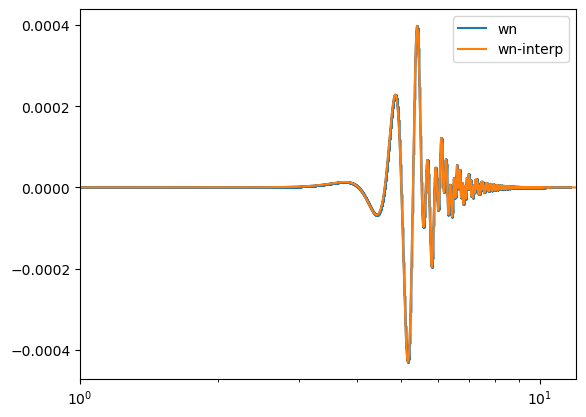

In [4]:
from scipy.interpolate import interp1d
from scipy.interpolate import InterpolatedUnivariateSpline
from scipy.integrate import simpson
from scipy.integrate import trapezoid

cell_worst = np.loadtxt("c_ell_chain3.txt")
cell_good = np.loadtxt("c_ell_chain2.txt")

wnlog = "/home/steven/WnLog/"
wn55 = np.loadtxt(wnlog + "WnLog5-60.00-300.00.table")

wn_interp = interp1d(wn55[:,0],wn55[:,1],kind='cubic',bounds_error=False,fill_value=0)
# wn_spline = InterpolatedUnivariateSpline(wn55[:,0],wn55[:,1])
my_ell_lin = np.linspace(0,10000,300000)
my_ell_log = np.logspace(0,np.log10(12),5000)
wn_ell_interp = wn_interp(my_ell_log)
# wn_ell_spline = wn_spline(my_ell)

plt.semilogx(wn55[:,0],wn55[:,1],label="wn",marker='.',markersize=0.1)
plt.semilogx(my_ell_log,wn_ell_interp,label="wn-interp")
# plt.semilogx(my_ell,wn_ell_spline,label="wn-spline")
# plt.semilogx(ells,cell_worst*1e4,label="worst")
# plt.semilogx(ells,cell_good*1e4,label="good")
plt.xlim(1,12)
# plt.ylim(-0.00035,0.00065)
plt.legend()
plt.show()
# np.where(np.log10(wn55[1:,0]) == -np.inf)

# En_good = 1/(2*np.pi)*trapezoid(my_ell_log*cell_good*wn_ell_interp)
# En_worst = 1/(2*np.pi)*trapezoid(my_ell_log*cell_worst*wn_ell_interp)
# print(En_good)
# print(En_worst)

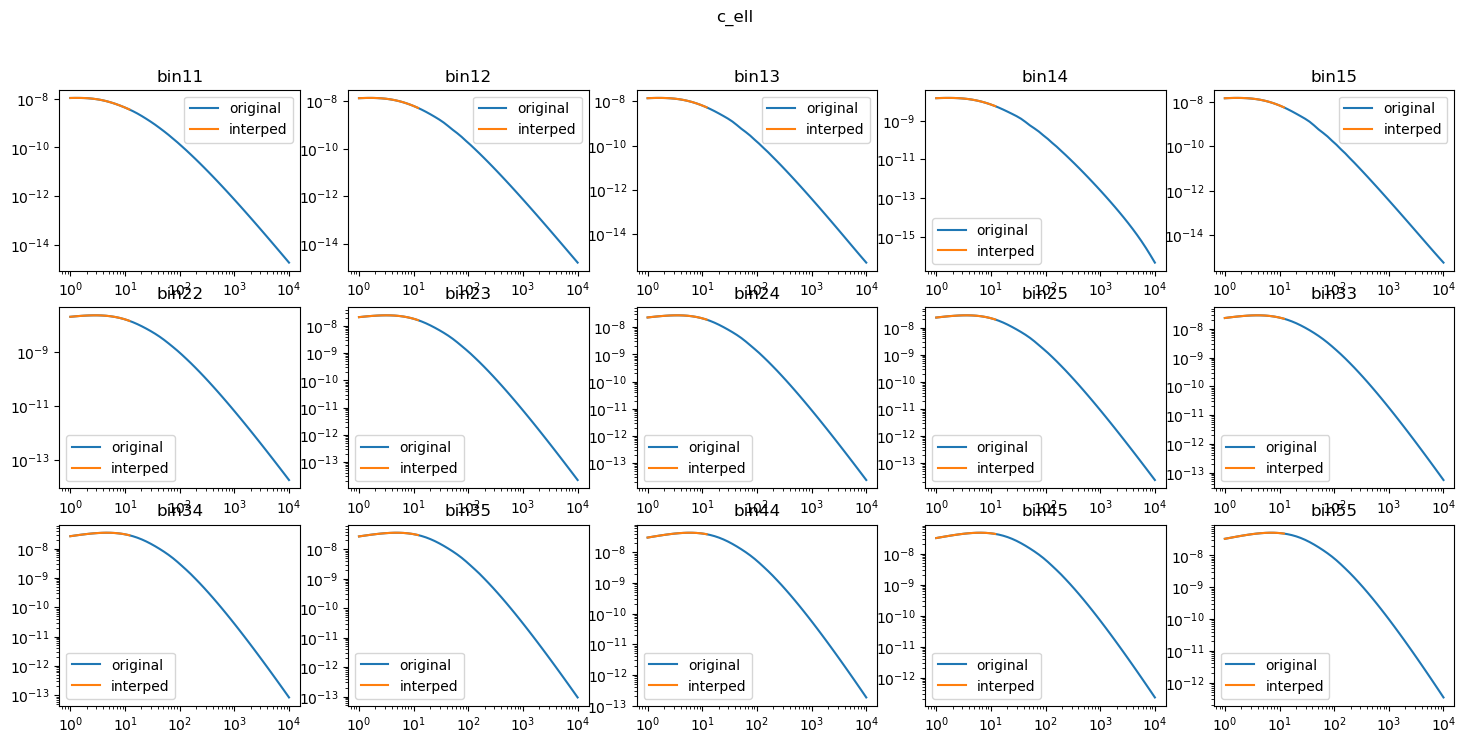

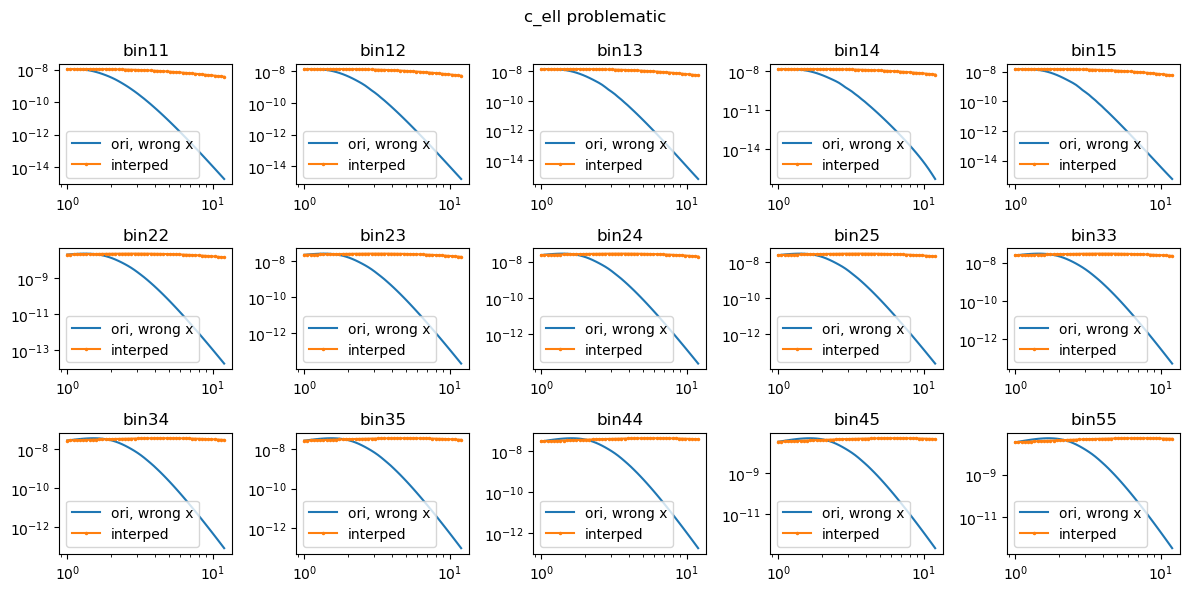

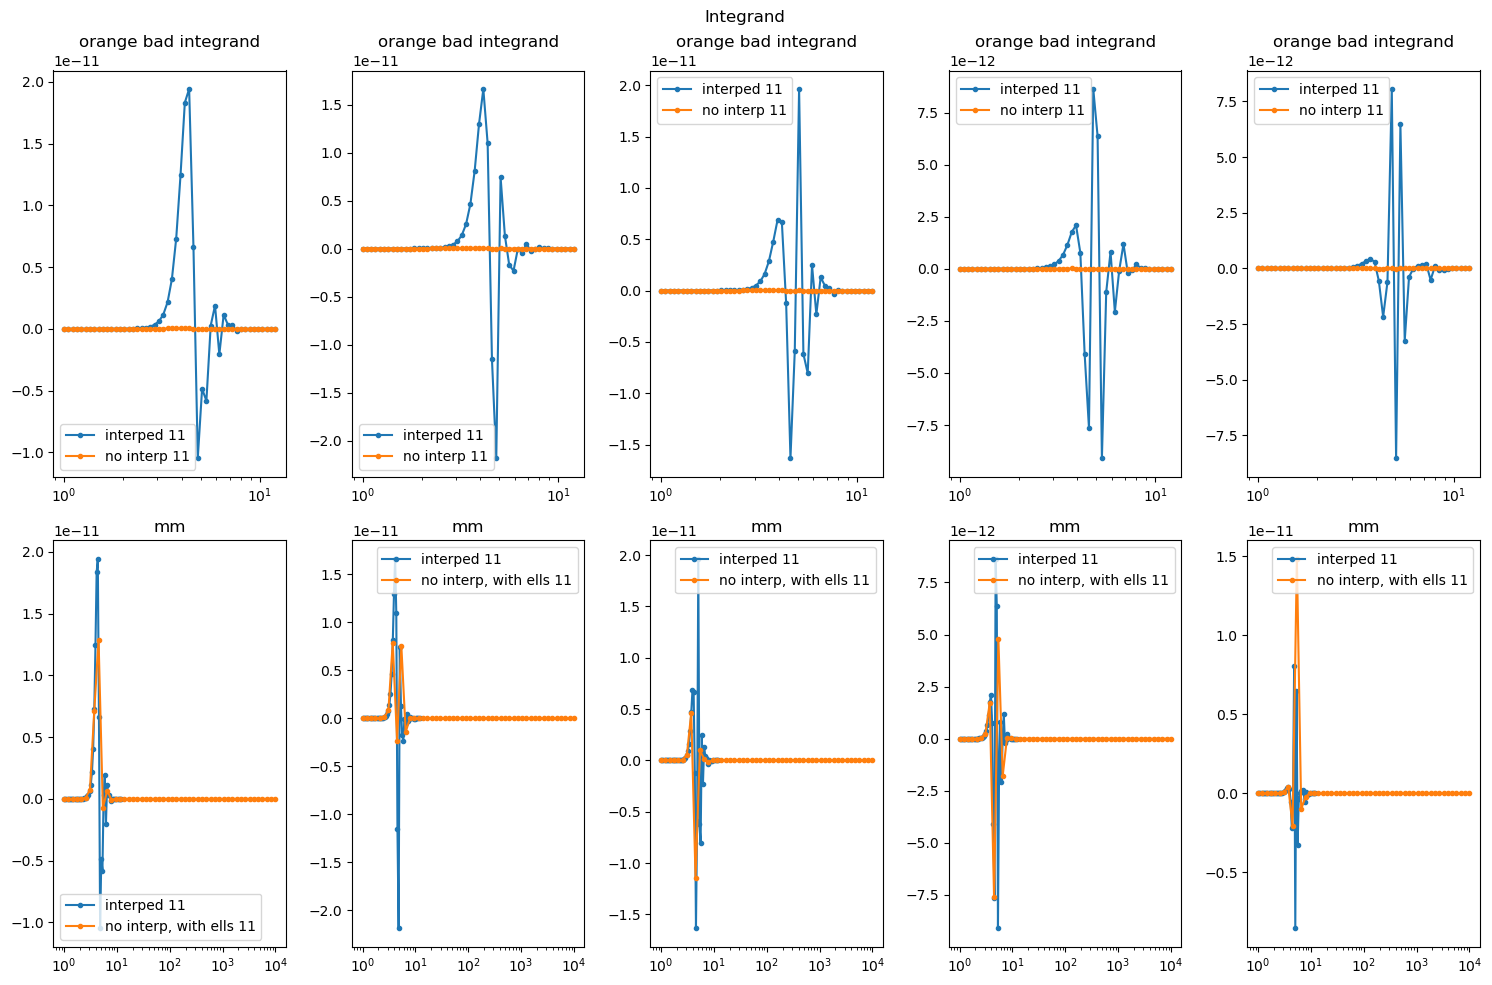

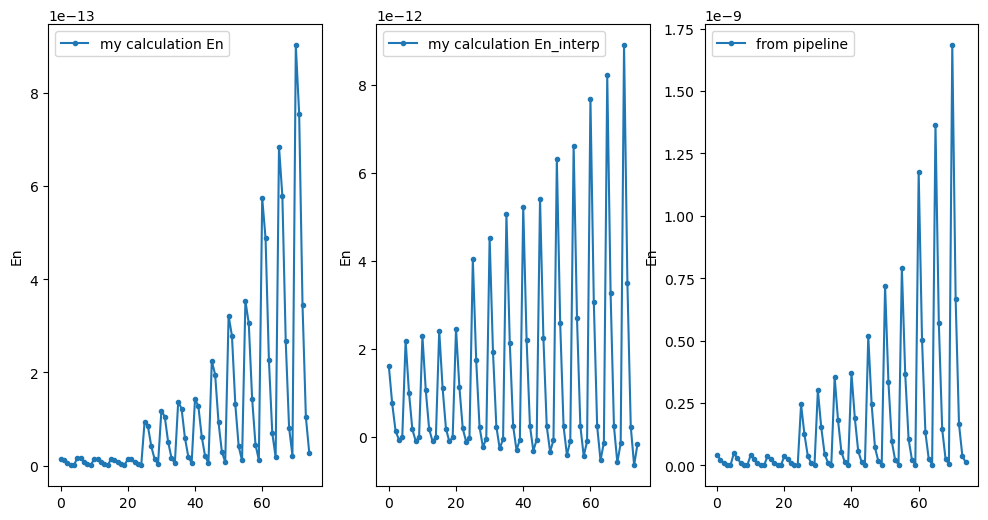

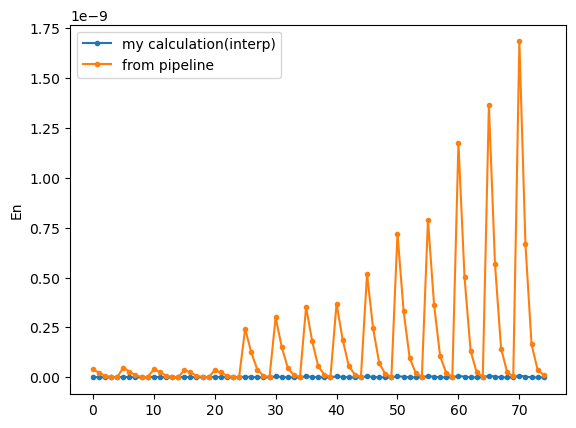

In [8]:
from scipy.interpolate import interp1d
from scipy.interpolate import InterpolatedUnivariateSpline
from scipy.integrate import simpson
from scipy.integrate import trapezoid

# cell_worst = np.loadtxt("c_ell_chain3.txt")
# cell_good = np.loadtxt("c_ell_chain2.txt")

ells = np.loadtxt("ellsme.txt")
# my_ell_log_dum = np.logspace(0,np.log10(12),50)
my_ell_log = np.logspace(0,np.log10(12),50)
c_ell_lcdm = {}
c_ell_lcdm_interp = {}
c_ell_lcdm_interped = {}
fig1 , axes1 = plt.subplots(3,5, figsize=(18,8))
fig2 , axes2 = plt.subplots(3,5, figsize=(12,6))
n1 = 0
m1 = 0
n2=0
m2=0
for i in range(1,6) :
    for j in range(i,6) :
        c_ell_lcdm[f"{i}{j}"] = np.loadtxt(f"c_ell_lcdm_{j}_{i}.txt")
        c_ell_lcdm_interp[f"{i}{j}"] = interp1d(ells, c_ell_lcdm[f"{i}{j}"],kind='cubic',bounds_error = False, fill_value=0)
        c_ell_lcdm_interped[f"{i}{j}"] = c_ell_lcdm_interp[f"{i}{j}"]([my_ell_log])[0]
        axes1[n1,m1].loglog(ells,c_ell_lcdm[f"{i}{j}"],label="original")
        axes1[n1,m1].loglog(my_ell_log,c_ell_lcdm_interped[f"{i}{j}"],label="interped")
        axes1[n1,m1].legend()
        axes1[n1,m1].set_title(f"bin{i}{j}")
        m1+=1
        if m1==5 :
            n1+=1
            m1=0

        ## Problematic part
        axes2[n2,m2].loglog(my_ell_log,c_ell_lcdm[f"{i}{j}"], label="ori, wrong x")
        axes2[n2,m2].loglog(my_ell_log,c_ell_lcdm_interped[f"{i}{j}"], label="interped", marker = '.',markersize = 3)
        axes2[n2,m2].legend()
        axes2[n2,m2].set_title(f"bin{i}{j}")
        # axes2[n2,m2].set_ylim(1e-14,1e-8)
        m2+=1
        if m2 ==5 :
            n2+=1
            m2=0

fig1.suptitle("c_ell")
fig2.suptitle("c_ell problematic")
plt.tight_layout()
plt.show()


folder = "/home/steven/WnLog/"
wn = {}
wn_interp = {}
wn_interped = {}
wn_interped_ells = {}
for i in range(5) :
    wn[i+1] = np.loadtxt(folder + f"WnLog{i+1}-60.00-300.00.table")
    wn_interp[i+1] = interp1d(wn[i+1][:,0],wn[i+1][:,1],kind='cubic',bounds_error=False,fill_value=0)
    wn_interped[i+1] = wn_interp[i+1](my_ell_log)
    wn_interped_ells[i+1] = wn_interp[i+1](ells)


n1=0
m1=0
fig,axes = plt.subplots(2,5, figsize=(15,10))
En = []
En_interp = []
En_ori_good = []
for i in range(1,6) :
    for j in range(i,6) :
        for n in range(5) :
            En_interp.append(1/(2*np.pi)*trapezoid(my_ell_log*c_ell_lcdm_interped[f"{i}{j}"]*wn_interped[n+1],x=my_ell_log))
            En.append(1/(2*np.pi)*trapezoid(my_ell_log*c_ell_lcdm[f"{i}{j}"]*wn_interped[n+1],x=my_ell_log)) ## Bad, should be integrated wrt ells, not my_ell_log
            En_ori_good.append(1/(2*np.pi)*trapezoid(ells*c_ell_lcdm[f"{i}{j}"]*wn_interped_ells[n+1],x=ells))
            if i==1 and j==1 :
                axes[0,m1].semilogx(my_ell_log,my_ell_log*c_ell_lcdm_interped[f"{i}{j}"]*wn_interped[n+1],label=f"interped {i}{j}",marker='.')
                axes[0,m1].semilogx(my_ell_log,my_ell_log*c_ell_lcdm[f"{i}{j}"]*wn_interped[n+1],label=f"no interp {i}{j}",marker='.') # Should be ells instead of my_ell_log
                axes[1,m1].semilogx(my_ell_log,my_ell_log*c_ell_lcdm_interped[f"{i}{j}"]*wn_interped[n+1],label=f"interped {i}{j}",marker='.')
                axes[1,m1].semilogx(ells,ells*c_ell_lcdm[f"{i}{j}"]*wn_interped_ells[n+1],label=f"no interp, with ells {i}{j}", marker = '.') # Good one, but too few data points
                axes[0,m1].legend()
                axes[0,m1].set_title("orange bad integrand")
                axes[1,m1].legend()
                axes[1,m1].set_title("mm")
                m1+=1
                if m1==5:
                    n1+=1
                    m1=0
fig.suptitle("Integrand")
plt.tight_layout()
plt.show()

dt60 = np.loadtxt("data-theory_data60_theory60.txt")
plt.figure(figsize=(12,6))
plt.subplot(1,3,1)
plt.plot(En,marker = '.',label="my calculation En")
plt.legend()
plt.ylabel('En')
plt.subplot(1,3,2)
plt.plot(En_interp, marker='.',label="my calculation En_interp")
plt.legend()
plt.ylabel('En')
plt.subplot(1,3,3)
plt.plot(dt60[:,1],label="from pipeline",marker = '.')
plt.legend()
plt.ylabel('En')
plt.show()

plt.plot(En_interp, marker='.',label="my calculation(interp)")
plt.plot(dt60[:,1],label="from pipeline",marker = '.')
plt.ylabel('En')
plt.legend()

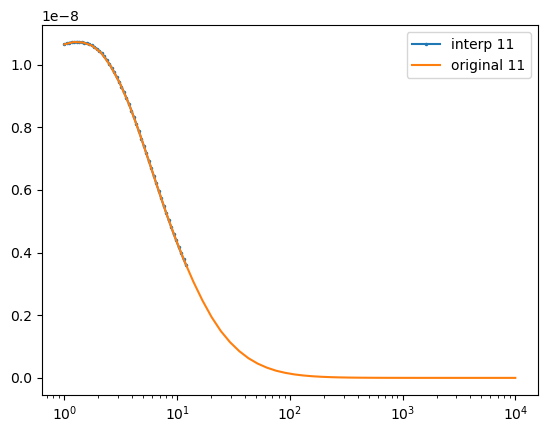

In [9]:
i=1
j=1
plt.semilogx(my_ell_log,c_ell_lcdm_interped[f"{i}{j}"], label=f"interp {i}{j}", marker = '.',markersize = 3)
plt.semilogx(ells,c_ell_lcdm[f"{i}{j}"], label=f"original {i}{j}")
plt.legend()

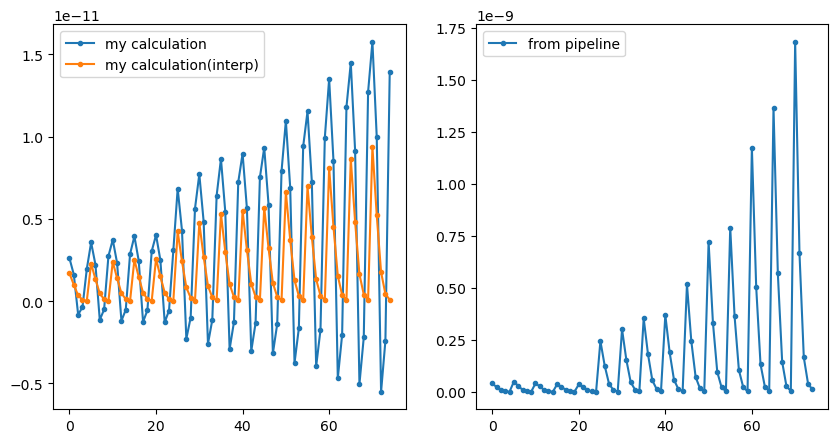

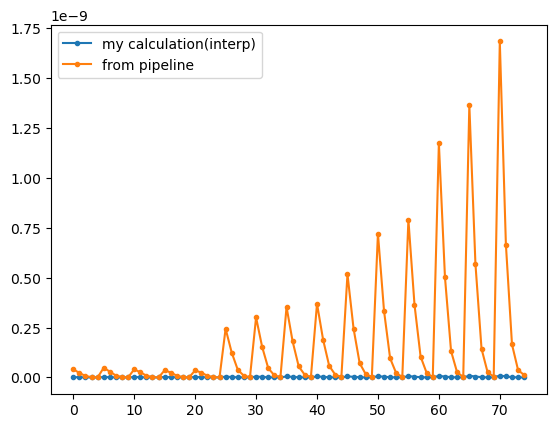

In [10]:
from scipy.interpolate import interp1d
from scipy.interpolate import InterpolatedUnivariateSpline
from scipy.integrate import simpson
from scipy.integrate import trapezoid

# cell_worst = np.loadtxt("c_ell_chain3.txt")
# cell_good = np.loadtxt("c_ell_chain2.txt")

ells = np.loadtxt("ellsme.txt")
# my_ell_log_dum = np.logspace(0,np.log10(12),50)
my_ell_log = np.logspace(0,np.log10(12),5000)
c_ell_lcdm = {}
c_ell_lcdm_interp = {}
c_ell_lcdm_interped = {}
for i in range(1,6) :
    for j in range(i,6) :
        c_ell_lcdm[f"{i}{j}"] = np.loadtxt(f"c_ell_lcdm_{j}_{i}.txt")
        c_ell_lcdm_interp[f"{i}{j}"] = interp1d(ells, c_ell_lcdm[f"{i}{j}"],kind='cubic',bounds_error = False, fill_value=0)
        c_ell_lcdm_interped[f"{i}{j}"] = c_ell_lcdm_interp[f"{i}{j}"]([my_ell_log])[0]

folder = "/home/steven/WnLog/"
wn = {}
wn_interp = {}
wn_interped = {}
wn_interped_ells = {}
for i in range(5) :
    wn[i+1] = np.loadtxt(folder + f"WnLog{i+1}-60.00-300.00.table")
    wn_interp[i+1] = interp1d(wn[i+1][:,0],wn[i+1][:,1],kind='cubic',bounds_error=False,fill_value=0)
    wn_interped[i+1] = wn_interp[i+1](my_ell_log)
    wn_interped_ells[i+1] = wn_interp[i+1](ells)



En = []
En_interp = []
for i in range(1,6) :
    for j in range(i,6) :
        for n in range(5) :
            En.append(1/(2*np.pi)*trapezoid(ells*c_ell_lcdm[f"{i}{j}"]*wn_interped_ells[n+1],x=ells))
            En_interp.append(1/(2*np.pi)*trapezoid(my_ell_log*c_ell_lcdm_interped[f"{i}{j}"]*wn_interped[n+1],x=my_ell_log))
            # if i==1 and j==1 :
            #     # plt.loglog(my_ell_log,c_ell_lcdm_interped[f"{i}{j}"], label="interp", marker = '.',markersize = 3)
            #     # plt.loglog(ells,c_ell_lcdm[f"{i}{j}"], label="original")
            #     # plt.legend()
            #     plt.semilogx(my_ell_log,my_ell_log*c_ell_lcdm_interped[f"{i}{j}"]*wn_interped[n+1],label=f"interped {i}{j}",marker='.')
            #     plt.semilogx(ells,ells*c_ell_lcdm[f"{i}{j}"]*wn_interped_ells[n+1],label=f"no interp {i}{j}",marker='.')
            #     plt.legend()
            #     plt.show()
            #     plt.loglog(ells,c_ell_lcdm[f"{i}{j}"], marker = '.', label=f"no interp {i}{j}")
            #     plt.loglog(my_ell_log,c_ell_lcdm_interped[f"{i}{j}"], marker = '.', label=f"interped {i}{j}")
            #     plt.legend()
            #     plt.show()

dt60 = np.loadtxt("data-theory_data60_theory60.txt")
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(En,marker = '.',label="my calculation")
plt.plot(En_interp, marker='.',label="my calculation(interp)")
plt.legend()
plt.subplot(1,2,2)
plt.plot(dt60[:,1],label="from pipeline",marker = '.')
plt.legend()
plt.show()

plt.plot(En_interp, marker='.',label="my calculation(interp)")
plt.plot(dt60[:,1],label="from pipeline",marker = '.')
plt.legend()

114591.55902616464


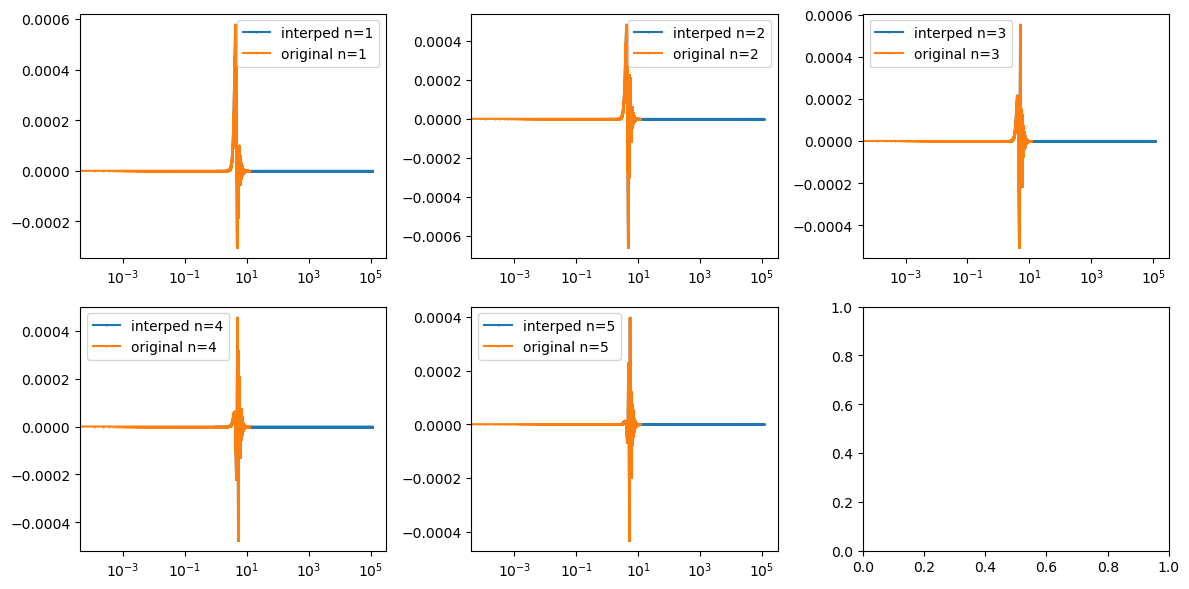

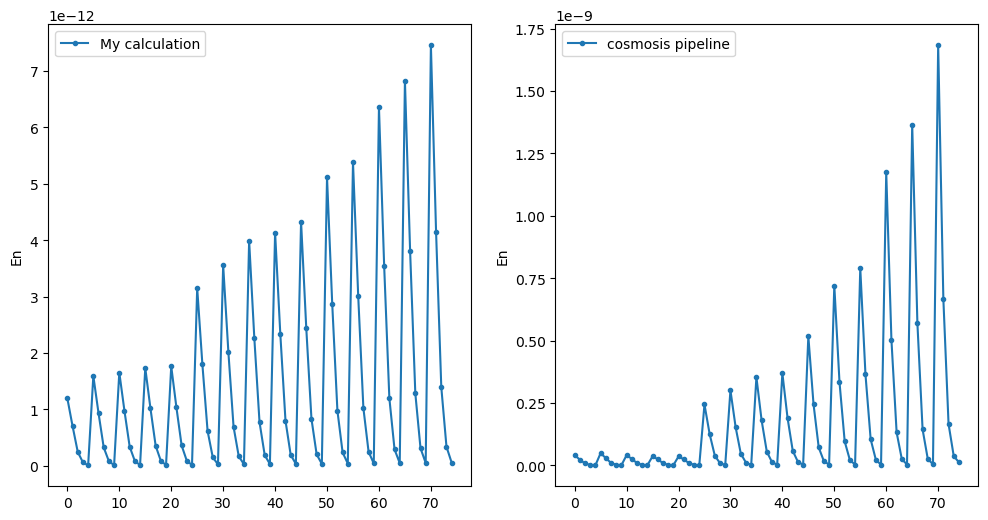

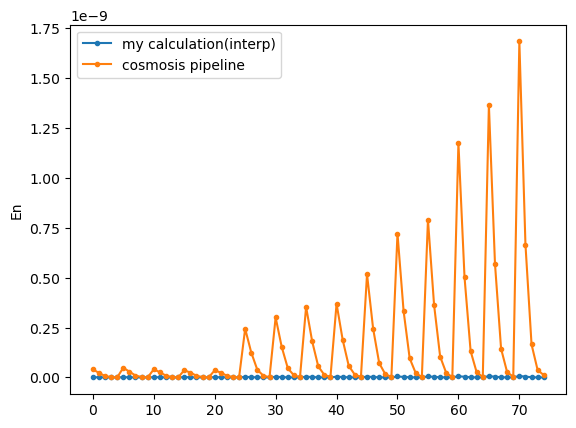

In [11]:
from scipy.interpolate import interp1d
from scipy.interpolate import InterpolatedUnivariateSpline
from scipy.integrate import simpson
from scipy.integrate import trapezoid

# cell_worst = np.loadtxt("c_ell_chain3.txt")
# cell_good = np.loadtxt("c_ell_chain2.txt")

ells = np.loadtxt("ellsme.txt")
# my_ell_log_dum = np.logspace(0,np.log10(12),50)
thetamax = 300/60*np.pi/180
LHIGH = 500*20/thetamax
print(LHIGH)
my_ell_log = np.logspace(0,np.log10(LHIGH),5000)
c_ell_lcdm = {}
c_ell_lcdm_interp = {}
c_ell_lcdm_interped = {}
for i in range(1,6) :
    for j in range(1,i+1) :
        c_ell_lcdm[f"{i}{j}"] = np.loadtxt(f"c_ell_lcdm_{i}_{j}_60.txt")
        c_ell_lcdm_interp[f"{i}{j}"] = interp1d(ells, c_ell_lcdm[f"{i}{j}"],kind='cubic',bounds_error = False, fill_value=0)
        c_ell_lcdm_interped[f"{i}{j}"] = c_ell_lcdm_interp[f"{i}{j}"]([my_ell_log])

folder = "/home/steven/WnLog/"
wn = {}
wn_interp = {}
wn_interped = {}
wn_interped_ells = {}
for i in range(5) :
    wn[i+1] = np.loadtxt(folder + f"WnLog{i+1}-60.00-300.00.table")
    wn_interp[i+1] = interp1d(wn[i+1][:,0],wn[i+1][:,1],kind='cubic',bounds_error=False,fill_value=0)
    wn_interped[i+1] = wn_interp[i+1](my_ell_log)
    wn_interped_ells[i+1] = wn_interp[i+1](ells)

fig,axes = plt.subplots(2,3,figsize=(12,6))
nn=0
for n in range(5) :
    nnn=n
    if n>=3:
        nn=1
        nnn=n-3
    axes[nn,nnn].semilogx(my_ell_log,wn_interped[n+1],label=f"interped n={n+1}",marker='.',markersize=1)
    axes[nn,nnn].semilogx(wn[n+1][:,0],wn[n+1][:,1],label=f"original n={n+1}",marker='.',markersize=1)
    axes[nn,nnn].legend()
plt.tight_layout()
plt.show()

En_interp = []
for i in range(1,6) :
    for j in range(i,6) :
        for n in range(5) :
            En_interp.append(1/(2*np.pi)*trapezoid(my_ell_log*c_ell_lcdm_interped[f"{j}{i}"]*wn_interped[n+1],x=my_ell_log))
        
dt60 = np.loadtxt("data-theory_data60_theory60.txt")
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.plot(En_interp, marker='.',label="My calculation")
plt.ylabel('En')
plt.legend()
plt.subplot(1,2,2)
plt.plot(dt60[:,1],label="cosmosis pipeline",marker = '.')
plt.legend()
plt.ylabel('En')
plt.show()

plt.plot(En_interp, marker='.',label="my calculation(interp)")
plt.plot(dt60[:,1],label="cosmosis pipeline",marker = '.')
plt.ylabel('En')
plt.legend()